https://medium.com/analytics-vidhya/pytorch-for-deep-learning-lstm-for-sequence-data-d0708fdf5717

In [61]:
import numpy as np
import torch
import matplotlib.pyplot as plt

Tworzymy sinusoidę.
LSTM pobiera sekwencje wejściowe, więc dane wejściowe są następujące:
Wejście: [punkt 1, punkt 2, punkt 3....., punkt n] przewidywanie: [punkt n+1].
Potrzebujemy wielu takich wierszy, aby utworzyć zbiór danych.

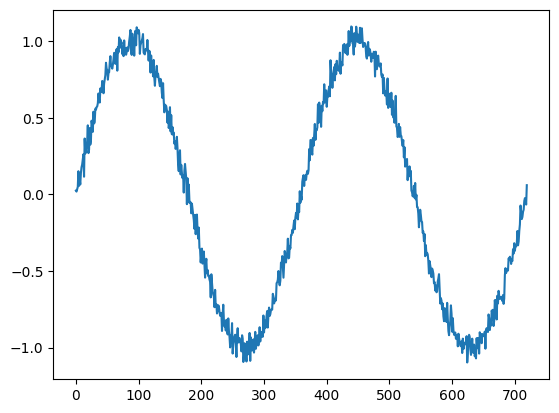

In [62]:
#creating the dataset
x = np.arange(1,721,1)
y = np.sin(x*np.pi/180)  + np.random.randn(720)*0.05
plt.plot(y)

In [63]:
# structuring the data
X = []
Y = []
for i in range(0,710):
     list1 = []
     for j in range(i,i+10):
         list1.append(y[j])
     X.append(list1)
     Y.append(y[j+1])

Zewnętrzna pętla (używająca i) iteruje 710 razy.
    Wewnętrzna pętla (używająca j) iteruje 10 razy, tworząc listę o nazwie list1, która zawiera 10 kolejnych wartości z tablicy y (która przechowuje dane fali sinusoidalnej z szumem).
    Po zakończeniu wewnętrznej pętli lista1 (reprezentująca sekwencję wejściową 10 punktów danych) jest dołączana do listy X.
    Wartość bezpośrednio następująca po 10-punktowej sekwencji ( y[j+1] ) jest dołączana do listy Y, służąc jako wartość docelowa dla tej sekwencji.

Mówiąc prościej, kod ten tworzy przesuwne okno 10 punktów danych z oryginalnych danych y. Każde okno jest sekwencją wejściową (X), a punkt danych bezpośrednio po oknie jest odpowiadającym mu docelowym wynikiem (Y). W ten sposób dane są skonstruowane do użycia z LSTM, który oczekuje sekwencji danych jako danych wejściowych.

In [64]:
#Podział na zbiór uczący i testowy (początek zbioru 360 wierszy, to część ucząca)
X = np.array(X)
Y = np.array(Y)
x_train = X[:360]
x_test = X[360:]
y_train = Y[:360]
y_test = Y[360:]
len(x_train),len(x_test),len(y_train),len(y_test)

(360, 350, 360, 350)

Zobaczymy jak wyglądają dane testowe. Są to ciągi 10 wartości. takich ciągów jest 360.

In [65]:
x_train[0], x_train[1], x_train[2]

(array([0.02533986, 0.01870637, 0.03504462, 0.04917778, 0.15170085,
        0.05621376, 0.09993146, 0.06538825, 0.14067119, 0.17777254]),
 array([0.01870637, 0.03504462, 0.04917778, 0.15170085, 0.05621376,
        0.09993146, 0.06538825, 0.14067119, 0.17777254, 0.19546718]),
 array([0.03504462, 0.04917778, 0.15170085, 0.05621376, 0.09993146,
        0.06538825, 0.14067119, 0.17777254, 0.19546718, 0.2281336 ]))

In [66]:
x_train.shape

(360, 10)

In [67]:
y_train[:21]


array([0.19546718, 0.2281336 , 0.2623339 , 0.11582784, 0.36504701,
       0.2671695 , 0.27642163, 0.32521159, 0.34729562, 0.45113871,
       0.26978083, 0.2927328 , 0.43340664, 0.3254104 , 0.35578211,
       0.48136975, 0.45021088, 0.40900483, 0.54030924, 0.46310292,
       0.47314295])

In [68]:
y_train.shape

(360,)

In [69]:
from torch.utils.data import Dataset

class timeseries(Dataset):
    def __init__(self,x,y):
        self.x = torch.tensor(x,dtype=torch.float32)
        self.y = torch.tensor(y,dtype=torch.float32)
        self.len = x.shape[0]

    def __getitem__(self,idx):
        return self.x[idx],self.y[idx]

    def __len__(self):
        return self.len

dataset = timeseries(x_train,y_train)#dataloader
from torch.utils.data import DataLoader
train_loader = DataLoader(dataset,shuffle=True,batch_size=256)

**__getitem__(self, idx)**: umożliwia dostęp do poszczególnych punktów danych w zbiorze danych przy użyciu ich indeksu (idx).

In [70]:
#Budowa modelu LSTM
from torch import nn

class neural_network(nn.Module):
    def __init__(self):
        super(neural_network,self).__init__()
        self.lstm = nn.LSTM(input_size=1,hidden_size=5,num_layers=1,batch_first=True)# sprawdź model z hidden_size=10,40
        self.fc1 = nn.Linear(in_features=5,out_features=1) #in_features musi być równe hidden_size

    def forward(self,x):
        output,_status = self.lstm(x)
        output = output[:,-1,:]
        output = self.fc1(torch.relu(output))
        return output

model = neural_network()

In [71]:
# optimizer , loss
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.0001)
epochs = 1500

In [72]:
  y_pred = model(data[:][0].view(-1,10,1)).reshape(-1)
  y_pred

tensor([0.4871, 0.4876, 0.4921, 0.5010, 0.4912, 0.5091, 0.5027, 0.5115, 0.5123,
        0.4933, 0.5026, 0.5030, 0.5081, 0.4981, 0.5091, 0.5143, 0.5127, 0.4857,
        0.5031, 0.4877, 0.4850, 0.4821, 0.5113, 0.5060, 0.4858, 0.5014, 0.4920,
        0.5138, 0.4916, 0.4998, 0.4919, 0.4837, 0.5042, 0.4988, 0.4865, 0.4978,
        0.4929, 0.5057, 0.4879, 0.4879, 0.5144, 0.4949, 0.5034, 0.5049, 0.5068,
        0.4993, 0.5124, 0.4976, 0.4907, 0.5018, 0.4858, 0.5104, 0.5101, 0.4830,
        0.5119, 0.4995, 0.5015, 0.4928, 0.4882, 0.4952, 0.5014, 0.4983, 0.4998,
        0.5095, 0.4878, 0.4858, 0.4917, 0.5060, 0.5087, 0.4892, 0.4903, 0.5002,
        0.5049, 0.5078, 0.4917, 0.5019, 0.4822, 0.5038, 0.4925, 0.5008, 0.5052,
        0.4902, 0.5122, 0.5060, 0.4998, 0.5035, 0.4893, 0.4877, 0.5070, 0.5146,
        0.4886, 0.5064, 0.5021, 0.5045, 0.5083, 0.4966, 0.4882, 0.5132, 0.5120,
        0.5093, 0.4938, 0.4961, 0.4880, 0.5051], grad_fn=<ViewBackward0>)

In [73]:
#pętla ucząca
for i in range(epochs):
    for j,data in enumerate(train_loader):
        y_pred = model(data[:][0].view(-1,10,1)).reshape(-1)
        loss = criterion(y_pred,data[:][1])
        loss.backward()
        optimizer.step()
    if i%50 == 0:
        print(i,"th iteration : ",loss)

0 th iteration :  tensor(0.8705, grad_fn=<MseLossBackward0>)
50 th iteration :  tensor(0.6691, grad_fn=<MseLossBackward0>)
100 th iteration :  tensor(0.7592, grad_fn=<MseLossBackward0>)
150 th iteration :  tensor(0.7063, grad_fn=<MseLossBackward0>)
200 th iteration :  tensor(0.5915, grad_fn=<MseLossBackward0>)
250 th iteration :  tensor(0.4628, grad_fn=<MseLossBackward0>)
300 th iteration :  tensor(0.3633, grad_fn=<MseLossBackward0>)
350 th iteration :  tensor(0.3300, grad_fn=<MseLossBackward0>)
400 th iteration :  tensor(0.2586, grad_fn=<MseLossBackward0>)
450 th iteration :  tensor(0.2076, grad_fn=<MseLossBackward0>)
500 th iteration :  tensor(0.1835, grad_fn=<MseLossBackward0>)
550 th iteration :  tensor(0.1751, grad_fn=<MseLossBackward0>)
600 th iteration :  tensor(0.2143, grad_fn=<MseLossBackward0>)
650 th iteration :  tensor(0.2236, grad_fn=<MseLossBackward0>)
700 th iteration :  tensor(0.2372, grad_fn=<MseLossBackward0>)
750 th iteration :  tensor(0.2467, grad_fn=<MseLossBackwar


    data[:][0].view(-1,10,1): Przekształca dane wejściowe do formatu wymaganego dla modelu LSTM (batch_size, sequence_length, input_size).
    Tutaj 10 reprezentuje długość sekwencji, a 1 liczbę cech.
    model(...): Przekazuje przekształcone dane wejściowe do modelu w celu uzyskania prognoz (y_pred).
    reshape(-1): Spłaszcza przewidywania do 1-wymiarowego tensora.

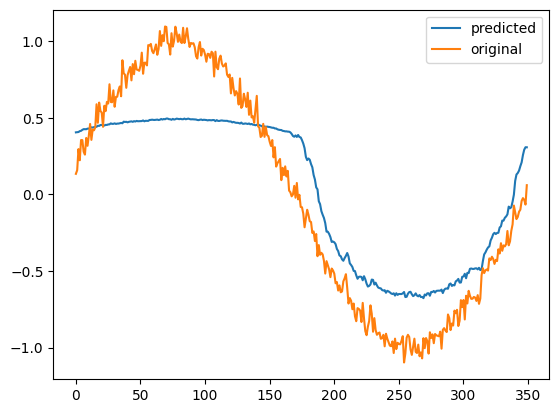

In [74]:
#Porównanie warrtości przewidywanych i rzeczywstych na zbiorze testowym
test_set = timeseries(x_test,y_test)
test_pred = model(test_set[:][0].view(-1,10,1)).view(-1)
plt.plot(test_pred.detach().numpy(),label='predicted')
plt.plot(test_set[:][1].view(-1),label='original')
plt.legend()